## **Handling Imbalanced Data**

### **Roadmap**

**1. Setup and Data Generation**

**2. Baseline Model Performance**

**3. Random Undersampling**

**4. Resampled Model Evaluation**

### **Setup and Data Generation**

Import libraries and generate an imbalanced dataset. A synthetic dataset isolates the mechanics of imbalance techniques.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
from imblearn.under_sampling import RandomUnderSampler

sns.set_theme(style="whitegrid")

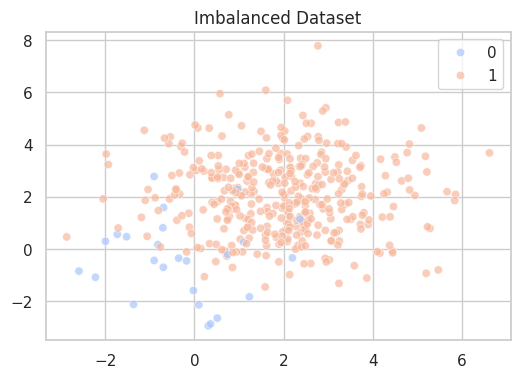

In [2]:
X, y = make_blobs(
    n_samples=[25, 375],
    centers=[(0, 0), (2, 2)],
    cluster_std=[1.5, 1.5],
    random_state=42
)

plt.figure(figsize=(6, 4))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="coolwarm", alpha=0.7)
plt.title("Imbalanced Dataset")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### **Baseline Model Performance**

Train a Logistic Regression model on the raw data. The baseline isolates the effect of the class imbalance before applying fixes.

In [3]:
baseline_model = LogisticRegression(random_state=42)
baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)
y_proba_baseline = baseline_model.predict_proba(X_test)[:, 1]

Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.71      0.71         7
           1       0.98      0.98      0.98       113

    accuracy                           0.97       120
   macro avg       0.85      0.85      0.85       120
weighted avg       0.97      0.97      0.97       120

Baseline ROC AUC Score: 0.9292


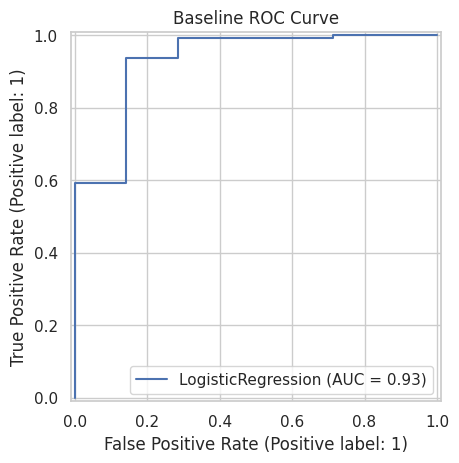

In [4]:
print("Baseline Classification Report:")
print(classification_report(y_test, y_pred_baseline))
print("Baseline ROC AUC Score:", round(roc_auc_score(y_test, y_proba_baseline), 4))

RocCurveDisplay.from_estimator(baseline_model, X_test, y_test)
plt.title("Baseline ROC Curve")
plt.show()

### **Random Undersampling**
 Remove samples randomly from the majority class to match the minority class count. Class balance forces the model to learn the minority class patterns. The dataset is large enough to absorb data loss.

Original class distribution: {1: 262, 0: 18}
Resampled class distribution: {0: 18, 1: 18}


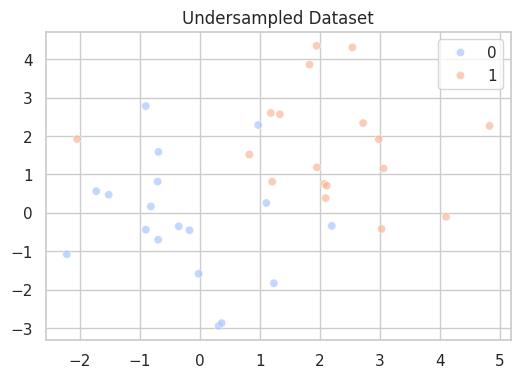

In [5]:
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print("Original class distribution:", pd.Series(y_train).value_counts().to_dict())
print("Resampled class distribution:", pd.Series(y_train_rus).value_counts().to_dict())

plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_train_rus[:, 0], y=X_train_rus[:, 1], hue=y_train_rus, palette="coolwarm", alpha=0.7)
plt.title("Undersampled Dataset")
plt.show()

### **Resampled Model Evaluation**

**What**: Train and evaluate a model using the balanced dataset.

**Why**: This tests the effectiveness of the undersampling technique.

In [6]:
rus_model = LogisticRegression(random_state=42)
rus_model.fit(X_train_rus, y_train_rus)

y_pred_rus = rus_model.predict(X_test)
y_proba_rus = rus_model.predict_proba(X_test)[:, 1]

RUS Classification Report:
              precision    recall  f1-score   support

           0       0.25      0.86      0.39         7
           1       0.99      0.84      0.91       113

    accuracy                           0.84       120
   macro avg       0.62      0.85      0.65       120
weighted avg       0.95      0.84      0.88       120

RUS ROC AUC Score: 0.9279


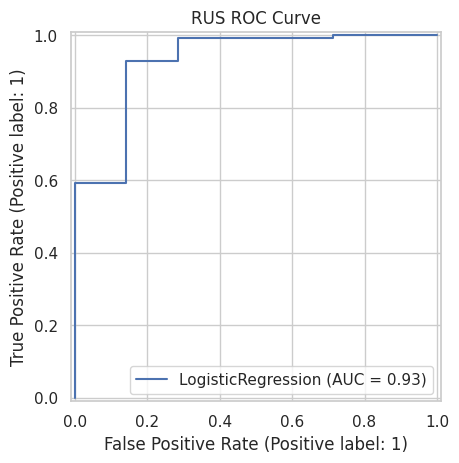

In [7]:
print("RUS Classification Report:")
print(classification_report(y_test, y_pred_rus))
print("RUS ROC AUC Score:", round(roc_auc_score(y_test, y_proba_rus), 4))

RocCurveDisplay.from_estimator(rus_model, X_test, y_test)
plt.title("RUS ROC Curve")
plt.show()

### **Key Revision Notes**

* Imbalanced data creates a bias toward the majority class.
* Random Undersampling forces class parity by deleting majority samples.
* Accuracy is a flawed metric for imbalanced configurations.
* F1-Score and ROC AUC are the correct evaluation metrics.